# ABI

## Forward-симулятор рынка

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from typing import List
from tqdm import tqdm

In [4]:
def prospect_value_function(x: float, alpha=0.8, beta=0.8, lam=2.25) -> float:
    if x >= 0:
        return x ** alpha
    
    return -lam * ((-x) ** beta)

In [5]:
def prospect_np(x: np.array, alpha: float=0.8, beta: float=0.8, lam: float=2.25) -> np.array:
    res = np.zeros_like(x, dtype=float)

    pos = x >= 0
    neg = x < 0

    res[pos] = x[pos] ** alpha
    res[neg] = -lam * ((-x[neg]) ** beta)

    return res

In [6]:
def softmax(x: np.array) -> np.array:
    exp_input = np.exp(x)
    exp_input_sum = np.sum(exp_input)

    return exp_input / exp_input_sum

In [7]:
class Provider:
    def __init__(self, name: str, p: np.array):
        self.name = name
        self.p = p

    def __repr__(self):
        return f"Provider '{self.name}': {self.p}"

In [8]:
class Agent:
    def __init__(self, w: np.array, ref: np.array, directions: np.array):
        self.w = w 
        self.ref = ref
        self.directions = directions
        self.current_provider = -1
        self.switching_cost = 0

    def utility_for(self, option: np.array):
        deltas = (option - self.ref) * self.directions
        prospect_activation = prospect_np(deltas)

        return (prospect_activation @ self.w).item()
    
    def utility_for_matrix(self, options: np.array):
        deltas = (options - self.ref) * self.directions
        prospect_activation = prospect_np(deltas)
        utilities = prospect_activation @ self.w
        return utilities.flatten()

    
    def activated_output_for(self, providers: List[Provider], actiavtion_func) -> np.array:
        utilities = np.array([self.utility_for(provider.p) for provider in providers])
        return actiavtion_func(utilities)
    
    def __repr__(self):
        return f"Agent[w={np.round(self.w, 2)}, ref={np.round(self.ref, 2)}, sw_cost={self.switching_cost}, current_provider={self.current_provider}]"

In [9]:
rules = {
    'price': {
        'min': 0,
        'max': 100,
        'expected': 50,
        'std': 15
    },
    'connection_speed': {
        'min': 0,
        'max': 1_000,
        'expected': 100,
        'std': 15
    },
    'quality': {
        'min': 0,
        'max': 100,
        'expected': 50,
        'std': 15
    },
}

def normalize(value: float, key: str) -> float:
    mn = rules[key]['min']
    mx = rules[key]['max']
    return (value - mn) / (mx - mn)

def clip_to_bounds(value: float, key: str) -> float:
    mn = rules[key]['min']
    mx = rules[key]['max']
    return float(np.clip(value, mn, mx))

In [10]:
def utility_range(agents: List[Agent], providers: List[Provider]):
    values = np.zeros(len(agents) * len(providers))
    idx = 0
    for agent in agents:
        for provider in providers:
            u = agent.utility_for(provider.p)
            values[idx] = u
            idx += 1

    return np.round(values.min(), 3), np.round(values.max(), 3), np.round(values.std(), 3)

In [11]:
def init_agents(amount: int, providers: List[Provider]) -> List[Agent]:
    weights = np.array([0.15, 0.25, 0.3]) / 0.7
    directions = np.array([-1, 1, 1])
    res = []

    for _ in range(amount):
        price_ref = np.random.normal(rules['price']['expected'], rules['price']['std'])
        speed_ref = np.random.normal(rules['connection_speed']['expected'], rules['connection_speed']['std'])
        quality_ref = np.random.normal(rules['quality']['expected'], rules['quality']['std'])

        price_ref = clip_to_bounds(price_ref, 'price')
        speed_ref = clip_to_bounds(speed_ref, 'connection_speed')
        quality_ref = clip_to_bounds(quality_ref, 'quality')

        ref = np.array([
            normalize(price_ref, 'price'),
            normalize(speed_ref, 'connection_speed'),
            normalize(quality_ref, 'quality')
        ])

        res.append(Agent(weights, ref, directions))

    sample_agents = np.random.choice(res, amount // 5)
    u_min, u_max, u_std = utility_range(sample_agents, providers)
    u_range = u_max - u_min

    print(f"Utility function: min={u_min}, max={u_max}, std={u_std}. Range={u_range}")

    for agent in res:
        agent.switching_cost = np.random.normal(u_std, 0.3 * u_std)

    return res


In [12]:
def init_providers() -> List[Provider]:
    res = []

    res.append(Provider("Wir", np.array(
        [
            normalize(70, 'price'),
            normalize(600, 'connection_speed'),
            normalize(70, 'quality')
        ])))
    
    res.append(Provider("Competitior1", np.array(
        [
            normalize(40, 'price'),
            normalize(100, 'connection_speed'),
            normalize(40, 'quality')
        ])))
    
    res.append(Provider("Competitior2", np.array(
        [
            normalize(90, 'price'),
            normalize(900, 'connection_speed'),
            normalize(75, 'quality')
        ])))

    return res

In [13]:
providers = init_providers()

providers

[Provider 'Wir': [0.7 0.6 0.7],
 Provider 'Competitior1': [0.4 0.1 0.4],
 Provider 'Competitior2': [0.9  0.9  0.75]]

In [14]:
M = 10_000
T = 104
LR = 0.1

In [15]:
agents = init_agents(M, providers)

agents[0:5]

Utility function: min=-0.736, max=0.554, std=0.208. Range=1.29


[Agent[w=[0.21 0.36 0.43], ref=[0.47 0.07 0.47], sw_cost=0.24980438676068065, current_provider=-1],
 Agent[w=[0.21 0.36 0.43], ref=[0.45 0.11 0.45], sw_cost=0.2974001545504828, current_provider=-1],
 Agent[w=[0.21 0.36 0.43], ref=[0.29 0.1  0.36], sw_cost=0.23507149325335597, current_provider=-1],
 Agent[w=[0.21 0.36 0.43], ref=[0.56 0.07 0.43], sw_cost=0.2302556097488229, current_provider=-1],
 Agent[w=[0.21 0.36 0.43], ref=[0.29 0.08 0.44], sw_cost=0.23181081229263456, current_provider=-1]]

In [16]:
agent = agents[0]
for p in providers:
    print(agent.utility_for(p.p))
print(agent.activated_output_for(providers, softmax))

0.19763639660108276
-0.06577106354772706
0.2164708175678538
[0.35875191 0.27567527 0.36557282]


In [17]:
class Simulator:
    def __init__(self, T: int, LR: float):
        self.T = T
        self.LR = LR

    @staticmethod
    def __find_equilibrium_step(history, window=20, eps=1e-2, patience=4):
        T, N = history.shape
        stable_count = 0

        for t in range(2 * window, T):
            prev_mean = history[t - 2 * window : t - window].mean(axis=0)
            curr_mean = history[t - window : t].mean(axis=0)

            shift = np.max(np.abs(curr_mean - prev_mean))

            if shift < eps:
                stable_count += 1
                if stable_count >= patience:
                    return t - window, curr_mean
            else:
                stable_count = 0

        return None, history[-window:].mean(axis=0)

    def run(self, agents, providers):
        M = len(agents)

        market_share_history = np.zeros(shape=(self.T, len(providers)))
        providers_idxes = np.arange(0, len(providers))
        provider_options = np.array([provider.p for provider in providers])

        for t in tqdm(range(self.T)):
            agent_choices = np.zeros(shape=len(providers))

            for agent in agents:
                utilities = agent.utility_for_matrix(provider_options)
                if agent.current_provider != -1:
                    utilities -= agent.switching_cost
                    utilities[agent.current_provider] += agent.switching_cost

                logit_probs = softmax(utilities)

                choice = np.random.choice(providers_idxes, p=logit_probs)
                agent_choices[choice] += 1
                provider = providers[choice]
                agent.ref = (1 - self.LR) * agent.ref + self.LR * provider.p
                agent.current_provider = choice
            
            market_share_history[t] = agent_choices / M

        eq_step, eq_shares = Simulator.__find_equilibrium_step(market_share_history)

        return eq_step, eq_shares, market_share_history


In [18]:
class VectorizedSimulator:
    def __init__(self, T: int, LR: float):
        self.T = T
        self.LR = LR
        self.rng = np.random.default_rng()

    @staticmethod
    def __find_equilibrium_step(history, window=20, eps=1e-2, patience=4):
        T, N = history.shape

        pad = np.vstack([np.zeros((1, N), dtype=history.dtype), np.cumsum(history, axis=0)])
        window_means = (pad[window:] - pad[:-window]) / window  # (T-window+1, N)

        shifts = np.max(np.abs(window_means[window:] - window_means[:-window]), axis=1)

        stable_count = 0
        for i, shift in enumerate(shifts, start=2 * window - 1):
            if shift < eps:
                stable_count += 1
                if stable_count >= patience:
                    eq_step = i - window + 1
                    return eq_step, window_means[eq_step]
            else:
                stable_count = 0

        return None, window_means[-1]
    
    def __gumbel_random_choice(self, utilities: np.array) -> int:
        U = self.rng.random(utilities.shape, dtype=np.float32)
        U = np.clip(U, 1e-8, 1 - 1e-8)
        gumbel_noise = -np.log(-np.log(U))
        return np.argmax(utilities + gumbel_noise, axis=1)

    def run(self, agents, providers):
        M = len(agents)
        P = len(providers)

        market_share_history = np.zeros((self.T, P), dtype=np.float32)

        provider_options = np.ascontiguousarray(
            np.stack([p.p for p in providers]).astype(np.float32)
        )

        refs = np.ascontiguousarray(np.stack([a.ref for a in agents]).astype(np.float32))
        current = np.array([a.current_provider for a in agents], dtype=np.int32)
        switch_cost = np.array([a.switching_cost for a in agents], dtype=np.float32)

        weights = np.asarray(agents[0].w, dtype=np.float32).reshape(-1)
        directions = np.asarray(agents[0].directions, dtype=np.float32).reshape(-1)

        for t in range(self.T):
            deltas = (provider_options[None, :, :] - refs[:, None, :]) * directions[None, None, :]
            activation = prospect_np(deltas)
            utilities = np.tensordot(activation, weights, axes=([2], [0]))  # (M, P)

            utilities -= switch_cost[:, None]

            valid = current >= 0
            rows = np.nonzero(valid)[0]
            utilities[rows, current[valid]] += switch_cost[valid]

            choices = self.__gumbel_random_choice(utilities)           

            counts = np.bincount(choices, minlength=P).astype(np.float32)
            market_share_history[t] = counts / M

            refs = (1 - self.LR) * refs + self.LR * provider_options[choices]
            current = choices.astype(np.int32)

        eq_step, eq_shares = VectorizedSimulator.__find_equilibrium_step(market_share_history)
        return eq_step, eq_shares, market_share_history


In [19]:
simulator = VectorizedSimulator(T, 0.2)

eq_step, eq_shares, market_share_history = simulator.run(agents, providers)

print(f"Equilibrium occurred on step: {eq_step}. Equilibrium market shares: {np.round(eq_shares, 2)}")

Equilibrium occurred on step: 27. Equilibrium market shares: [0.38 0.19 0.43]


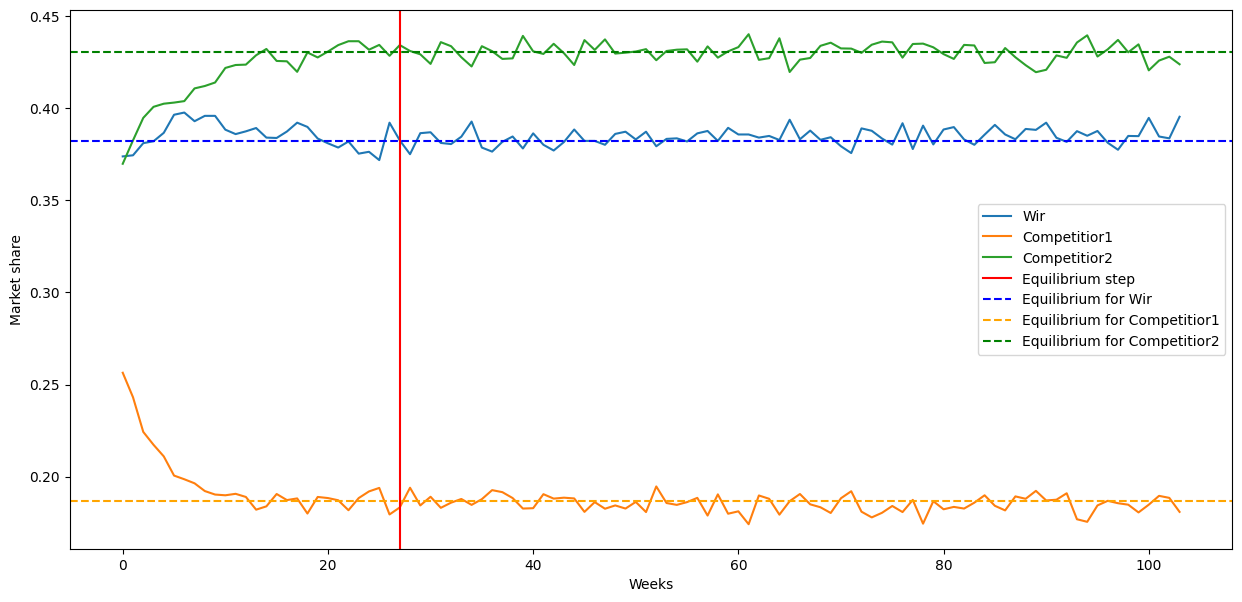

In [20]:
colors = ['blue', 'orange', 'green']

fig, ax = plt.subplots(figsize=(15, 7))

plt.plot(market_share_history, label=list(map(lambda x: x.name, providers)))

plt.axvline(eq_step, color='red', label='Equilibrium step')

for i, sh in enumerate(eq_shares):
    plt.axhline(sh, linestyle='dashed', linewidth=1.5, label=f'Equilibrium for {providers[i].name}', color=colors[i])

plt.xlabel("Weeks")
plt.ylabel("Market share")
plt.legend()

## Оптимизация равновесного состояния

Проблема: симулятор рынка стохастический. Классические методы оптимизации (вроде SGD) тут работать не будут, поскольку нет аналитических выражений и градиентов.

Приходим к задаче blackbox оптимизации: попробуем решить её с использованием Evolution strategy.

In [21]:
class MarketLoss:
    def __init__(self, target_share: float, our_idx: int = 0):
        self.target_share = target_share
        self.our_idx = our_idx

    def __call__(self, market_share: np.ndarray) -> float:
        return float((market_share[self.our_idx] - self.target_share) ** 2)


### ScenarioSampler (Discriminator)

Его задача - генерировать сценарии рынка $\varphi$

In [22]:
from dataclasses import dataclass
import numpy as np

@dataclass
class MarketScenario:
    n_agents: int
    ref_shift: np.ndarray      # shape (3,)
    ref_std: float             # scalar
    switching_cost_scale: float


In [23]:
def softplus(x):
    return np.log1p(np.exp(x))

def inverse_softplus(x):
    return np.log(np.exp(x) - 1)

def phi_to_vector(phi: MarketScenario) -> np.ndarray:
    return np.concatenate([
        phi.ref_shift,
        np.array([
            inverse_softplus(phi.ref_std),
            inverse_softplus(phi.switching_cost_scale)
        ], dtype=np.float32)
    ])



def vector_to_phi(vec: np.ndarray, n_agents: int) -> MarketScenario:
    vec = np.asarray(vec, dtype=np.float32)

    ref_shift = vec[0:3]
    ref_std = float(vec[3])
    switching_cost_scale = float(vec[4])

    ref_std = softplus(ref_std) + 1e-4
    switching_cost_scale = softplus(switching_cost_scale) + 1e-4

    return MarketScenario(
        n_agents=n_agents,
        ref_shift=ref_shift.copy(),
        ref_std=ref_std,
        switching_cost_scale=switching_cost_scale
    )



In [24]:
class ScenarioSampler:
    def __init__(self, base_phi: MarketScenario, sigma: np.ndarray, n_agents: int):
        self.phi = base_phi
        self.sigma = np.asarray(sigma, dtype=np.float32)
        self.n_agents = n_agents

        self.phi_vec = phi_to_vector(base_phi)

    def sample_population(self, n: int, mirrored: bool = True):
        d = self.phi_vec.shape[0]

        if mirrored:
            half = n // 2
            eps = np.random.normal(size=(half, d)).astype(np.float32)
            eps = np.vstack([eps, -eps])
            if n % 2 == 1:
                extra = np.random.normal(size=(1, d)).astype(np.float32)
                eps = np.vstack([eps, extra])
        else:
            eps = np.random.normal(size=(n, d)).astype(np.float32)

        samples = self.phi_vec[None, :] + self.sigma[None, :] * eps
        return [vector_to_phi(sample, self.n_agents) for sample in samples]

    def update(self, grad: np.ndarray, lr: float):
        self.phi_vec -= lr * grad
        self.phi = vector_to_phi(self.phi_vec, self.n_agents)


### Generator

Он хранит $\xi$ и двигает его в сторону уменьшения loss

In [25]:
class Generator:
    def __init__(self, base_xi: np.ndarray, sigma: np.ndarray):
        self.xi = np.asarray(base_xi, dtype=np.float32)      # (P, F)
        self.sigma = np.asarray(sigma, dtype=np.float32)     # (P, F)

    def sample_population(self, n: int, mirrored: bool = True) -> np.ndarray:
        shape = self.xi.shape  # (P, F)

        if mirrored:
            half = n // 2
            eps = np.random.normal(size=(half, *shape)).astype(np.float32)
            eps = np.vstack([eps, -eps])
            if n % 2 == 1:
                extra = np.random.normal(size=(1, *shape)).astype(np.float32)
                eps = np.vstack([eps, extra])
        else:
            eps = np.random.normal(size=(n, *shape)).astype(np.float32)

        return self.xi[None, :, :] + self.sigma[None, :, :] * eps

    def update(self, grad: np.ndarray, lr: float):
        self.xi -= lr * grad
        self.xi = np.clip(self.xi, 0.0, 1.0)


### Оценка эволюционного градиента

Пусть имеем некий параметр $\theta \in R^d$

Мы не можем напрямую вычислить $\nabla_{\theta}L(\theta)$, потому что симулятор стохастический и не имеет аналитического выражения.

Тогда можем сгенерировать "шумную" популяцию кандидатов:

$\theta_i = \theta + \sigma \cdot \varepsilon_i$, где 

- $\varepsilon_i \sim N_{0,1}$ - случайный шум
- $\sigma$ - вектор масштабов мутаций


И далее оценим эволюционный градиент как:

$\nabla J = \frac{1}{N} \sum_{i=1} ^{N} \overline{L_i} \varepsilon_i$

$\overline{L_i} = \frac{L_i - \mu_L}{\sigma_L + \varepsilon}$ - нормированный loss, где:

- $\mu_L$ - средний loss по популяции
- $\sigma_K$ - std loss по популяции
- $\varepsilon$ - малое число для устойчивости

In [26]:
def evolution_gradient(theta, population, losses, sigma):
    eps = (population - theta) / sigma

    # нормализация уменьшает дисперсию
    losses = (losses - losses.mean()) / (losses.std() + 1e-8)

    # делаем reshape автоматически под размерность eps
    reshape = (len(losses),) + (1,) * (eps.ndim - 1)
    losses = losses.reshape(reshape)

    grad = np.mean(losses * eps, axis=0)
    return grad


### Каркас обучения

In [27]:
def evaluate_candidate(simulator, loss_fn, xi, phi, build_providers, build_agents):
    providers = build_providers(xi)
    agents = build_agents(phi)

    eq_step, eq_shares, history = simulator.run(agents, providers)
    loss = loss_fn(eq_shares)

    return loss, eq_step, eq_shares, history


In [28]:
def train_adversarial_simple(
    simulator,
    generator,
    discriminator,
    loss_fn,
    build_providers,
    build_agents,
    outer_steps: int = 50,
    pop_size_xi: int = 4,
    pop_size_phi: int = 4,
    lr_g: float = 0.05,
    lr_d: float = 0.05,
):
    history = {
        "gen_loss": [],
        "disc_loss": [],
        "xi": [],
        "phi": [],
        "eq_share": [],
    }

    for step in tqdm(range(outer_steps)):
        # находим неприятный сценарий для текущего xi
        phi_pop = discriminator.sample_population(pop_size_phi, mirrored=True)

        disc_losses = []
        for phi in phi_pop:
            loss, _, _, _ = evaluate_candidate(
                simulator, loss_fn, generator.xi, phi, build_providers, build_agents
            )
            disc_losses.append(loss)

        disc_losses = np.asarray(disc_losses, dtype=np.float32)
        pop_phi_vec = np.array([phi_to_vector(phi) for phi in phi_pop], dtype=np.float32)

        grad_phi = evolution_gradient(
            discriminator.phi_vec,
            pop_phi_vec,
            disc_losses,
            discriminator.sigma
        )

        # дискриминатор максимизирует loss
        discriminator.update(-grad_phi, lr_d)

        # минимизируем loss на текущем худшем phi
        # берём лучший (хуже всего для нас) phi из этой маленькой популяции
        worst_idx = int(np.argmax(disc_losses))
        worst_phi = phi_pop[worst_idx]

        xi_pop = generator.sample_population(pop_size_xi, mirrored=True)

        gen_losses = []
        best_eq = None

        for xi in xi_pop:
            loss, eq_step, eq_shares, _ = evaluate_candidate(
                simulator, loss_fn, xi, worst_phi, build_providers, build_agents
            )
            gen_losses.append(loss)

            if best_eq is None or loss < min(gen_losses):
                best_eq = eq_shares

        gen_losses = np.asarray(gen_losses, dtype=np.float32)

        grad_xi = evolution_gradient(
            generator.xi,
            xi_pop,
            gen_losses,
            generator.sigma
        )

        generator.update(grad_xi, lr_g)

        history["gen_loss"].append(float(gen_losses.mean()))
        history["disc_loss"].append(float(disc_losses.mean()))
        history["xi"].append(generator.xi.copy())
        history["phi"].append(discriminator.phi_vec.copy())
        history["eq_share"].append(best_eq.copy() if best_eq is not None else None)

        print(
            f"step={step:04d} "
            f"gen_loss={history['gen_loss'][-1]:.4f} "
            f"disc_loss={history['disc_loss'][-1]:.4f}"
        )

    return history


### Генерация агентов и провайдеров

Нужно "подогнать" то, что уже реализовано в первом разделе, под необходимый формат для пайплайна обучения

#### Гиперпараметры

In [29]:
rules = {
    'price': {'min': 0, 'max': 100, 'expected': 50, 'std': 15},
    'connection_speed': {'min': 0, 'max': 1_000, 'expected': 100, 'std': 15},
    'quality': {'min': 0, 'max': 100, 'expected': 50, 'std': 15},
}

N_AGENTS = 5_000
T = 104
LR = 0.05
FEATURES = ['price', 'connection_speed', 'quality']
FEATURE_DIRECTIONS = np.array([-1.0, 1.0, 1.0], dtype=np.float32)
WEIGHTS = np.array([0.15, 0.25, 0.3], dtype=np.float32) / 0.7

In [30]:
def normalize(value: float, key: str) -> float:
    mn = rules[key]['min']
    mx = rules[key]['max']
    return (value - mn) / (mx - mn)


def denormalize(value: float, key: str) -> float:
    mn = rules[key]['min']
    mx = rules[key]['max']
    return value * (mx - mn) + mn


def clip_to_bounds(value: float, key: str) -> float:
    mn = rules[key]['min']
    mx = rules[key]['max']
    return float(np.clip(value, mn, mx))

#### Провайдеры

$\xi$ - параметры провайдера. Они уже определены, на данный момент это [price, connection_speedm quality]

In [31]:
def build_providers(xi: np.ndarray, competitors: np.ndarray) -> List[Provider]:
    xi = np.asarray(xi, dtype=np.float32).copy()
    xi = np.clip(xi, 0.0, 1.0)
    us = Provider(name="Wir", p=np.squeeze(xi))

    competitors = np.asarray(competitors, dtype=np.float32).copy()
    competitors = np.clip(competitors, 0.0, 1.0)
    n_competitors, _ = competitors.shape

    names = [f"Competitor_{i}" for i in range(n_competitors)]
    return [us] + [Provider(name=names[i], p=competitors[i]) for i in range(n_competitors)]

#### Агенты

In [32]:
@dataclass
class Agent:
    w: np.ndarray
    ref: np.ndarray
    directions: np.ndarray
    switching_cost: float = 0.0
    current_provider: int = -1

    def utility_for_matrix(self, options: np.ndarray):
        deltas = (options - self.ref) * self.directions
        prospect_activation = prospect_np(deltas)
        return prospect_activation @ self.w


def build_agents(phi: MarketScenario, n_agents: int):
    agents = []

    for _ in range(n_agents):
        ref = np.random.normal(
            loc=0.5 + phi.ref_shift,
            scale=phi.ref_std,
            size=3
        )

        ref = np.clip(ref, 0.0, 1.0)

        switching_cost = np.random.normal(0.2, 0.05)
        switching_cost *= phi.switching_cost_scale

        agents.append(
            Agent(
                w=WEIGHTS.copy(),
                ref=ref.astype(np.float32),
                directions=FEATURE_DIRECTIONS.copy(),
                switching_cost=float(max(1e-6, switching_cost))
            )
        )

    return agents



## Пробное обучение

In [51]:
phi = MarketScenario(
    n_agents=N_AGENTS,
    ref_shift=np.array([0.0, 0.0, 0.0], dtype=np.float32),
    ref_std=0.1,
    switching_cost_scale=0.3
)
sampler_sigma = np.array([
    0.05, 0.05, 0.05,   # ref_shift
    0.02,               # ref_std
    0.05                # switching_cost
], dtype=np.float32)
sampler = ScenarioSampler(phi, sampler_sigma, n_agents=N_AGENTS)


# price, connection, quality
xi_initial = np.array([[0.7, 0.6, 0.7]])

xi_competitors = np.array([
    [0.4, 0.1, 0.4],
    [0.7,  0.7,  0.75],
])

generator_sigma = np.array([
    [0.05, 0.02, 0.02]
])

generator = Generator(base_xi=xi_initial, sigma=generator_sigma)

simulator = VectorizedSimulator(T, LR)

target_share = 0.6
lf = MarketLoss(target_share)

In [52]:
print(xi_initial)
print(generator.sample_population(2))

[[0.7 0.6 0.7]]
[[[0.7244471  0.6112576  0.70748866]]

 [[0.6755529  0.58874243 0.6925113 ]]]


In [53]:
print(xi_competitors.shape)

(2, 3)


In [54]:
build_providers(xi_initial, xi_competitors)

[Provider 'Wir': [0.7 0.6 0.7],
 Provider 'Competitor_0': [0.4 0.1 0.4],
 Provider 'Competitor_1': [0.7  0.7  0.75]]

In [55]:
result = train_adversarial_simple(
    simulator=simulator,
    generator=generator,
    discriminator=sampler,
    loss_fn=lf,
    outer_steps=20,
    build_providers=lambda x: build_providers(x, competitors=xi_competitors),
    build_agents=lambda p: build_agents(p, N_AGENTS)
)

  5%|▌         | 1/20 [00:03<01:00,  3.21s/it]

step=0000 gen_loss=0.0456 disc_loss=0.0455


 10%|█         | 2/20 [00:06<00:56,  3.12s/it]

step=0001 gen_loss=0.0403 disc_loss=0.0407


 15%|█▌        | 3/20 [00:09<00:53,  3.15s/it]

...

step=0017 gen_loss=0.0047 disc_loss=0.0046


 95%|█████████▌| 19/20 [01:00<00:03,  3.16s/it]

step=0018 gen_loss=0.0040 disc_loss=0.0035


100%|██████████| 20/20 [01:03<00:00,  3.18s/it]

step=0019 gen_loss=0.0047 disc_loss=0.0039


In [56]:
last_xi = result['xi'][-1]

last_xi

array([[0.1906566, 0.8801149, 1.       ]], dtype=float32)

In [57]:
result['phi']

[array([ 0.03844856,  0.01568331, -0.01448528, -2.2492943 , -1.0742106 ],
       dtype=float32),
 array([ 0.04809806,  0.01789999,  0.00234528, -2.2473016 , -1.0551858 ],
       dtype=float32),
 array([ 0.0064228 ,  0.0322266 ,  0.03269797, -2.2763271 , -1.0320183 ],
       dtype=float32),
 array([-0.0087197 ,  0.04861642,  0.01871318, -2.295523  , -1.0361853 ],
       dtype=float32),
 array([ 0.00520015,  0.01745152,  0.04895477, -2.2969098 , -1.0029962 ],
       dtype=float32),
 array([ 8.7483088e-04,  3.1150702e-02,  9.3535334e-03, -2.2650828e+00,
        -1.0657840e+00], dtype=float32),
 array([ 0.0671347 ,  0.08185288, -0.06046006, -2.255811  , -1.0135071 ],
       dtype=float32),
 array([ 0.0788562 ,  0.05810291, -0.08558162, -2.2552638 , -0.99110365],
       dtype=float32),
 array([ 0.06159623,  0.10459001, -0.12374711, -2.2906473 , -0.97424054],
       dtype=float32),
 array([ 0.06447052,  0.10233368, -0.12755093, -2.2934146 , -0.97112334],
       dtype=float32),
 array([ 0.029

In [58]:
result['eq_share']

[array([0.3826999 , 0.19717999, 0.42012006], dtype=float32),
 array([0.40263   , 0.18702002, 0.41035014], dtype=float32),
 array([0.42329   , 0.18565007, 0.39105988], dtype=float32),
 array([0.42760998, 0.17920999, 0.39318004], dtype=float32),
 array([0.42993003, 0.18100004, 0.3890701 ], dtype=float32),
 array([0.43965998, 0.18149996, 0.37883997], dtype=float32),
 array([0.44947997, 0.17634001, 0.37418   ], dtype=float32),
 array([0.45543003, 0.17321   , 0.3713599 ], dtype=float32),
 array([0.45716017, 0.1719    , 0.37094006], dtype=float32),
 array([0.46780008, 0.17032997, 0.36187014], dtype=float32),
 array([0.46955007, 0.16790998, 0.36254016], dtype=float32),
 array([0.4775303 , 0.16859004, 0.35388002], dtype=float32),
 array([0.4780198 , 0.16707008, 0.35491005], dtype=float32),
 array([0.49142995, 0.1643    , 0.34427008], dtype=float32),
 array([0.4820799 , 0.16684003, 0.35108003], dtype=float32),
 array([0.5176498 , 0.15529999, 0.32705003], dtype=float32),
 array([0.5309596 , 0.15

In [59]:
providers = build_providers(last_xi, competitors=xi_competitors)

In [60]:
agents = build_agents(phi, N_AGENTS)

In [61]:
simulator = VectorizedSimulator(T, LR)

eq_step, eq_shares, market_share_history = simulator.run(agents, providers)

print(f"Equilibrium occurred on step: {eq_step}. Equilibrium market shares: {np.round(eq_shares, 2)}")

Equilibrium occurred on step: 57. Equilibrium market shares: [0.55 0.15 0.3 ]


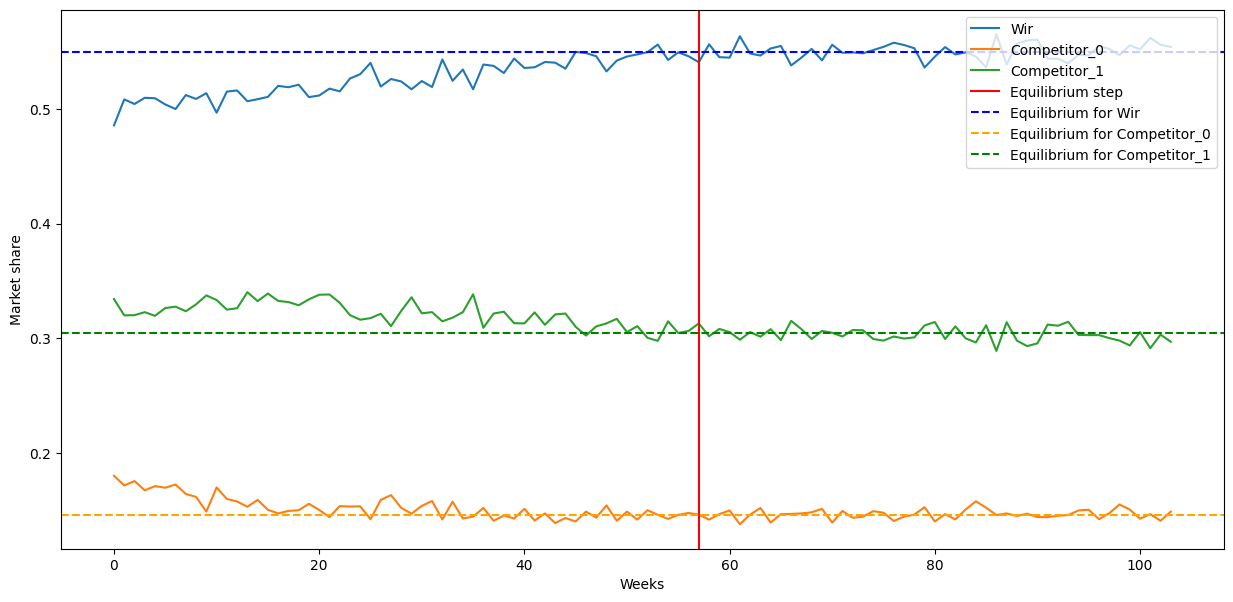

In [62]:
colors = ['blue', 'orange', 'green']

fig, ax = plt.subplots(figsize=(15, 7))

plt.plot(market_share_history, label=list(map(lambda x: x.name, providers)))

plt.axvline(eq_step, color='red', label='Equilibrium step')

for i, sh in enumerate(eq_shares):
    plt.axhline(sh, linestyle='dashed', linewidth=1.5, label=f'Equilibrium for {providers[i].name}', color=colors[i])

plt.xlabel("Weeks")
plt.ylabel("Market share")
plt.legend()